# Stock Return Prediction using Triple-Barrier Labeling

## 0. Imports

In [38]:
import os
import numpy as np
from typing import Optional, Tuple, List, Dict
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

## 1. Label Construction

### Configuration

In [2]:
# --------------------------------------------------
# Config
# --------------------------------------------------
DATA_DIR = "./data"
PANEL_FILE = os.path.join(DATA_DIR, "vn30_panel_daily.csv")
PROCESSED_OUT = os.path.join(DATA_DIR, "processed_vn30_panel_daily.csv")

START = "2018-01-01"
END   = "2026-03-15"

# Triple-barrier parameters
VOL_LOOKBACK = 20          # rolling vol window
VERTICAL_HORIZON = 10      # number of trading days forward
PT_MULT = 2.0              # profit-taking barrier = + PT_MULT * vol
SL_MULT = 2.0              # stop-loss barrier     = - SL_MULT * vol

### Load raw panel data

In [31]:
# --------------------------------------------------
# Load panel
# --------------------------------------------------
df = pd.read_csv(PANEL_FILE, parse_dates=["date"])

# --------------------------------------------------
# Basic cleaning
# --------------------------------------------------
print("Before cleaning:", len(df))

# remove duplicates
df = df.drop_duplicates(subset=["symbol", "date"]).copy()

# remove impossible rows
df = df[
    (df["close"] > 0) &
    (df["open"] > 0) &
    (df["high"] > 0) &
    (df["low"] > 0) &
    (df["volume"] >= 0)
].copy()

df = df.sort_values(["symbol", "date"]).reset_index(drop=True)
print("After cleaning:", len(df))

all_symbols = df["symbol"].unique()
print(all_symbols)
# Create a dictionary of DataFrames
symbols = {symbol: group for symbol, group in df.groupby("symbol")}
print(f"Created separate DataFrames for {len(symbols)} symbols.")
display(symbols["BID"].head())

Before cleaning: 61490
After cleaning: 61489
['ACB' 'BID' 'BVH' 'CTG' 'DGC' 'FPT' 'GAS' 'GVR' 'HDB' 'HPG' 'HSG' 'LPB'
 'MBB' 'MSN' 'MWG' 'PLX' 'PNJ' 'POW' 'SAB' 'SHB' 'SSI' 'STB' 'TCB' 'TPB'
 'VCB' 'VHM' 'VIB' 'VIC' 'VJC' 'VNM' 'VPB' 'VRE']
Created separate DataFrames for 32 symbols.


,date,symbol,open,high,low,close,volume
1918,2018-07-02,BID,13.92,14.19,13.29,13.51,3542250
1919,2018-07-03,BID,13.53,13.72,12.58,12.58,4944960
1920,2018-07-04,BID,12.58,12.63,11.98,12.50,4641640
1921,2018-07-05,BID,12.31,12.58,11.62,11.79,3044050
1922,2018-07-06,BID,11.68,12.61,11.38,12.61,5061910


### Compute Returns & Volatility

In [4]:
# --------------------------------------------------
# Returns and rolling volatility
# --------------------------------------------------
def add_returns_and_volatility(data: pd.DataFrame, vol_lookback: int = 20) -> pd.DataFrame:
    out = data.copy()

    # log return
    out["log_ret"] = (
        out.groupby("symbol")["close"]
        .transform(lambda s: np.log(s).diff())
    )

    # rolling realized volatility of daily log returns
    out["daily_vol"] = (
        out.groupby("symbol")["log_ret"]
        .transform(lambda s: s.rolling(vol_lookback, min_periods=vol_lookback).std())
    )

    return out

df = add_returns_and_volatility(df, vol_lookback=VOL_LOOKBACK)
print(df.head(30))

         date symbol  open  high   low  close   volume   log_ret  daily_vol
0  2018-07-02    ACB  6.87  6.87  6.33   6.43  6858520       NaN        NaN
1  2018-07-03    ACB  6.45  6.56  5.91   5.98  7375018 -0.072554        NaN
2  2018-07-04    ACB  5.89  6.18  5.89   6.18  4127586  0.032898        NaN
3  2018-07-05    ACB  6.04  6.18  5.69   5.77  4948503 -0.068646        NaN
4  2018-07-06    ACB  5.60  6.33  5.60   6.33  7854475  0.092628        NaN
5  2018-07-09    ACB  6.37  6.58  6.33   6.37  4587386  0.006299        NaN
6  2018-07-10    ACB  6.37  6.60  6.35   6.54  3244193  0.026338        NaN
7  2018-07-11    ACB  6.45  6.47  5.98   6.16  7023863 -0.059860        NaN
8  2018-07-12    ACB  6.76  6.76  6.16   6.39  4150902  0.036657        NaN
9  2018-07-13    ACB  6.39  6.66  5.98   6.60  3940996  0.032335        NaN
10 2018-07-16    ACB  6.66  6.79  6.60   6.66  3769038  0.009050        NaN
11 2018-07-17    ACB  6.93  6.93  6.54   6.87  5135363  0.031045        NaN
12 2018-07-1

### Triple-Barrier Labeling

In [5]:
# --------------------------------------------------
# Triple-barrier core
# --------------------------------------------------
def triple_barrier_for_symbol(
    g: pd.DataFrame,
    pt_mult: float = 2.0,
    sl_mult: float = 2.0,
    horizon: int = 10
) -> pd.DataFrame:
    """
    Apply triple-barrier labeling to one symbol.

    Required columns in g:
    date, symbol, close, high, low, daily_vol
    """
    n = len(g)

    labels = np.full(n, np.nan)
    hit_dates = [pd.NaT] * n
    hit_types = [None] * n
    vertical_dates = [pd.NaT] * n
    upper_barriers = np.full(n, np.nan)
    lower_barriers = np.full(n, np.nan)
    event_returns = np.full(n, np.nan)

    close_arr = g["close"].to_numpy()
    high_arr = g["high"].to_numpy()
    low_arr = g["low"].to_numpy()
    vol_arr = g["daily_vol"].to_numpy()
    date_arr = g["date"].to_numpy()

    for i in range(n):
        vol = vol_arr[i]

        # skip if volatility unavailable
        if np.isnan(vol):
            continue

        # vertical barrier index
        j_end = min(i + horizon, n - 1)
        if j_end <= i:
            continue

        entry = close_arr[i]
        upper = entry * np.exp(pt_mult * vol)
        lower = entry * np.exp(-sl_mult * vol)

        upper_barriers[i] = upper
        lower_barriers[i] = lower
        vertical_dates[i] = pd.Timestamp(date_arr[j_end])

        label = 0
        hit_idx = j_end
        hit_type = "vb"

        # scan forward to find first touch
        for j in range(i + 1, j_end + 1):
            up_hit = high_arr[j] >= upper
            dn_hit = low_arr[j] <= lower

            if up_hit and dn_hit:
                # ambiguous same-bar touch in daily OHLC data
                # conservative rule: compare close-to-bar distances using that day's open/close not available reliably
                # choose the barrier with smaller log distance from entry in absolute terms; if equal -> 0
                up_dist = np.log(upper / entry)
                dn_dist = abs(np.log(lower / entry))
                if up_dist < dn_dist:
                    label = 1
                    hit_idx = j
                    hit_type = "pt"
                elif dn_dist < up_dist:
                    label = -1
                    hit_idx = j
                    hit_type = "sl"
                else:
                    label = 0
                    hit_idx = j
                    hit_type = "ambiguous"
                break
            elif up_hit:
                label = 1
                hit_idx = j
                hit_type = "pt"
                break
            elif dn_hit:
                label = -1
                hit_idx = j
                hit_type = "sl"
                break

        labels[i] = label
        hit_dates[i] = pd.Timestamp(date_arr[hit_idx])
        hit_types[i] = hit_type
        event_returns[i] = np.log(close_arr[hit_idx] / entry)

    out = g.copy()
    out["tb_label"] = labels
    out["tb_hit_date"] = hit_dates
    out["tb_hit_type"] = hit_types
    out["tb_vertical_date"] = vertical_dates
    out["tb_upper_barrier"] = upper_barriers
    out["tb_lower_barrier"] = lower_barriers
    out["tb_event_log_return"] = event_returns

    return out

In [6]:
# --------------------------------------------------
# Apply to all symbols
# --------------------------------------------------
labeled_list = []

for symbol, g in df.groupby("symbol", sort=True):
    print(f"Labeling {symbol} ...")
    labeled_g = triple_barrier_for_symbol(
        g,
        pt_mult=PT_MULT,
        sl_mult=SL_MULT,
        horizon=VERTICAL_HORIZON
    )
    labeled_list.append(labeled_g)

labeled = pd.concat(labeled_list, axis=0, ignore_index=True)
labeled = labeled.sort_values(["symbol", "date"]).reset_index(drop=True)

print(labeled.head(30))

Labeling ACB ...
Labeling BID ...
Labeling BVH ...
Labeling CTG ...
Labeling DGC ...
Labeling FPT ...
Labeling GAS ...
Labeling GVR ...
Labeling HDB ...
Labeling HPG ...
Labeling HSG ...
Labeling LPB ...
Labeling MBB ...
Labeling MSN ...
Labeling MWG ...
Labeling PLX ...
Labeling PNJ ...
Labeling POW ...
Labeling SAB ...
Labeling SHB ...
Labeling SSI ...
Labeling STB ...
Labeling TCB ...
Labeling TPB ...
Labeling VCB ...
Labeling VHM ...
Labeling VIB ...
Labeling VIC ...
Labeling VJC ...
Labeling VNM ...
Labeling VPB ...
Labeling VRE ...
         date symbol  open  high   low  close   volume   log_ret  daily_vol  \
0  2018-07-02    ACB  6.87  6.87  6.33   6.43  6858520       NaN        NaN   
1  2018-07-03    ACB  6.45  6.56  5.91   5.98  7375018 -0.072554        NaN   
2  2018-07-04    ACB  5.89  6.18  5.89   6.18  4127586  0.032898        NaN   
3  2018-07-05    ACB  6.04  6.18  5.69   5.77  4948503 -0.068646        NaN   
4  2018-07-06    ACB  5.60  6.33  5.60   6.33  7854475  0.092

## 2. Data Visualization

### a. Price and Volume Over Time

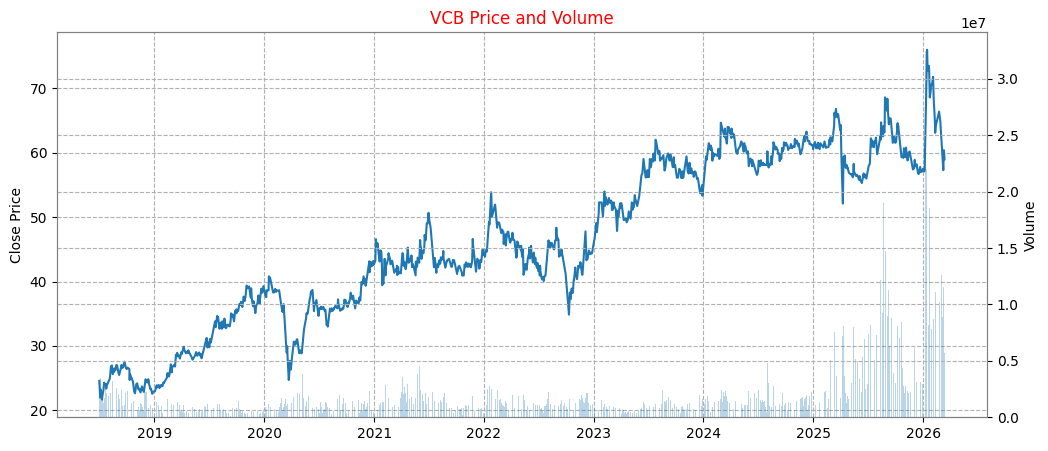

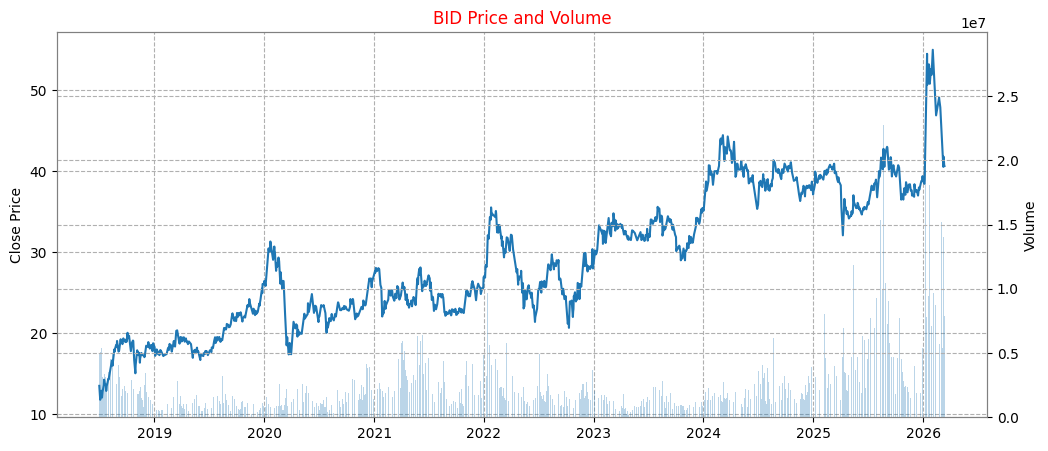

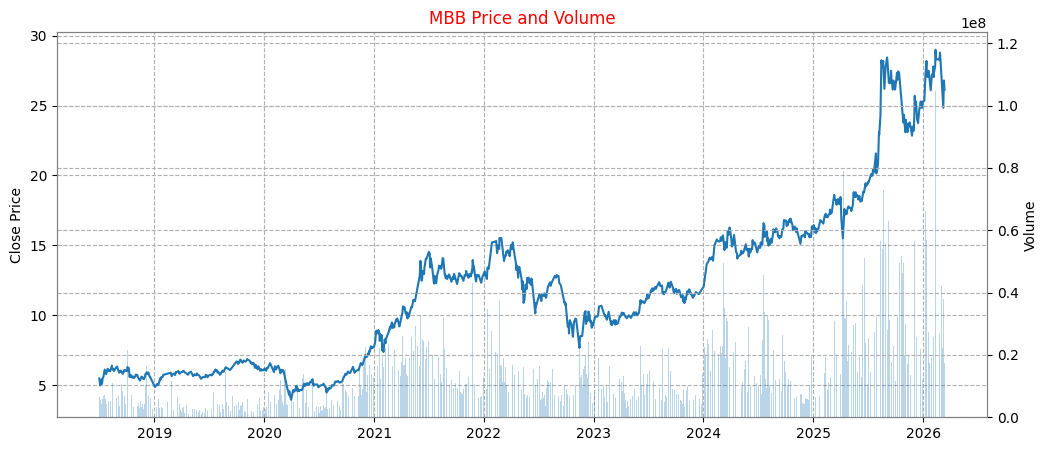

In [52]:
for name in ["VCB", "BID", "MBB"]:
    df = symbols[name].set_index("date")

    fig, ax1 = plt.subplots(figsize=(12,5))

    ax1.plot(df.index, df["close"])
    ax1.set_ylabel("Close Price")

    ax2 = ax1.twinx()
    ax2.bar(df.index, df["volume"], alpha=0.3)
    ax2.set_ylabel("Volume")

    plt.title(f"{name} Price and Volume")
    plt.show()

### b. Return Distribution

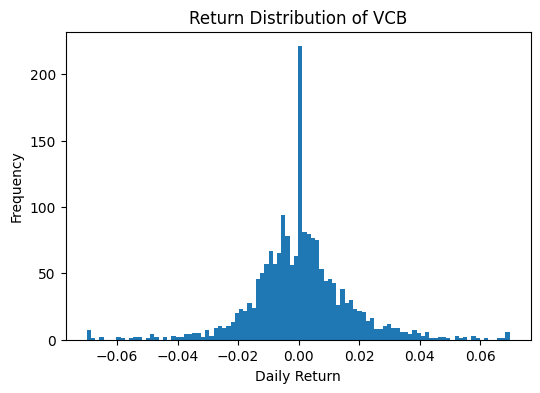

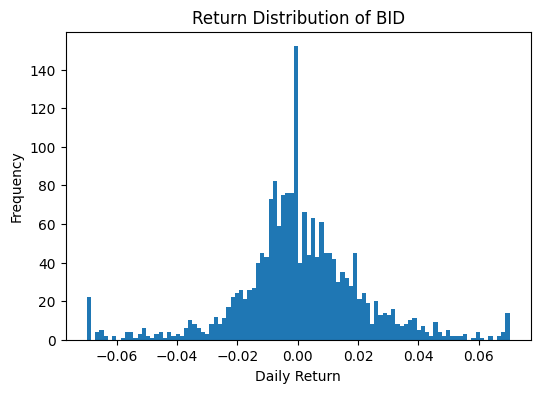

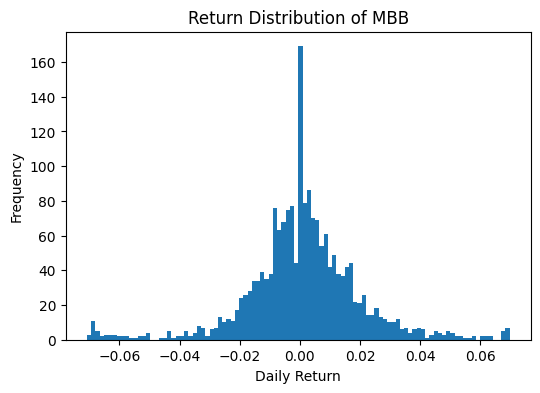

In [35]:
for name in ["VCB", "BID", "MBB"]:
    df = symbols[name]
    ret = df["close"].pct_change()

    plt.figure(figsize=(6,4))
    plt.hist(ret.dropna(), bins=100)
    plt.title("Return Distribution of " + name)
    plt.xlabel("Daily Return")
    plt.ylabel("Frequency")
    plt.show()

### c. Rolling Volatility

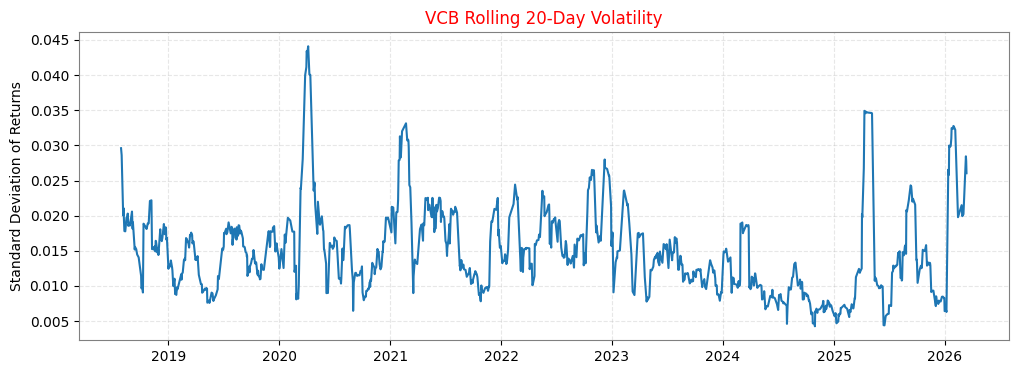

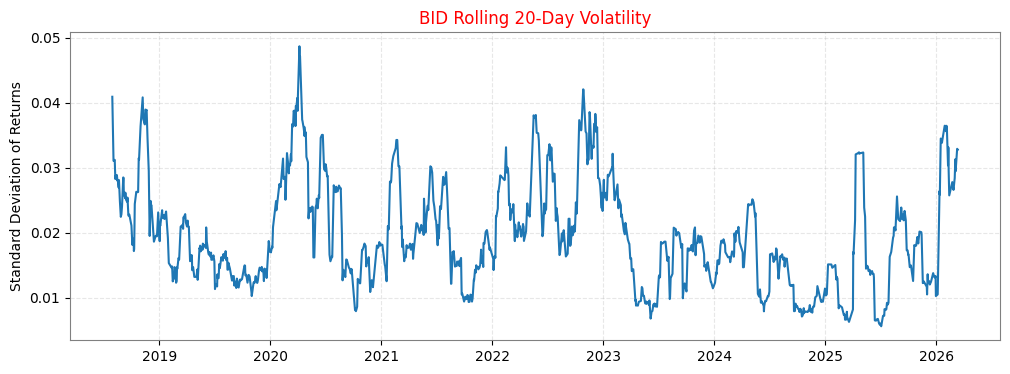

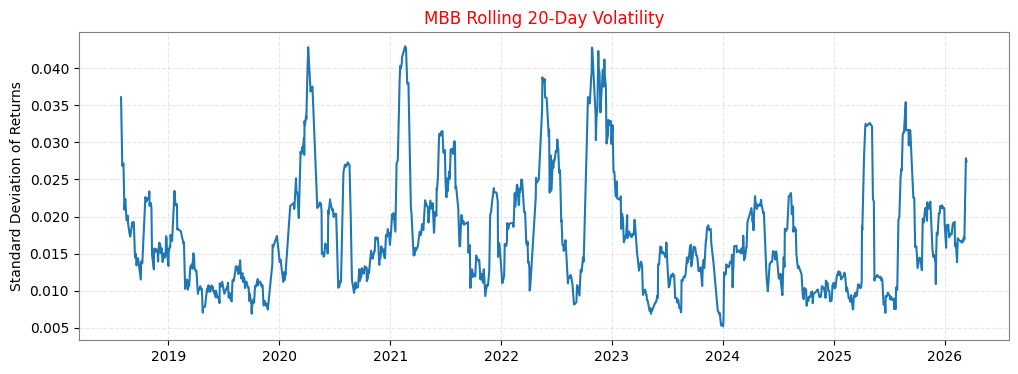

In [51]:
for name in ["VCB", "BID", "MBB"]:
    df = symbols[name].set_index("date") # Now index is the date
    ret = df["close"].pct_change()
    volatility_20 = ret.rolling(20).std()

    plt.figure(figsize=(12,4))
    plt.plot(df.index, volatility_20) # df.index is now a DatetimeIndex
    plt.title(f"{name} Rolling 20-Day Volatility")
    plt.ylabel("Standard Deviation of Returns")
    plt.grid(True, alpha=0.3)
    plt.show()

### d. Candlestick Chart - Open, Close, High, Low, Volumn

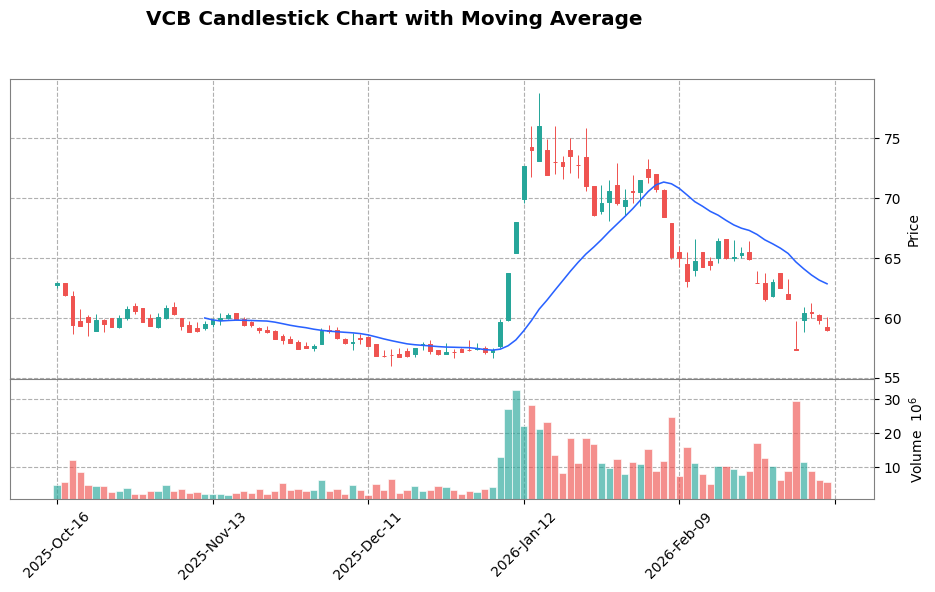

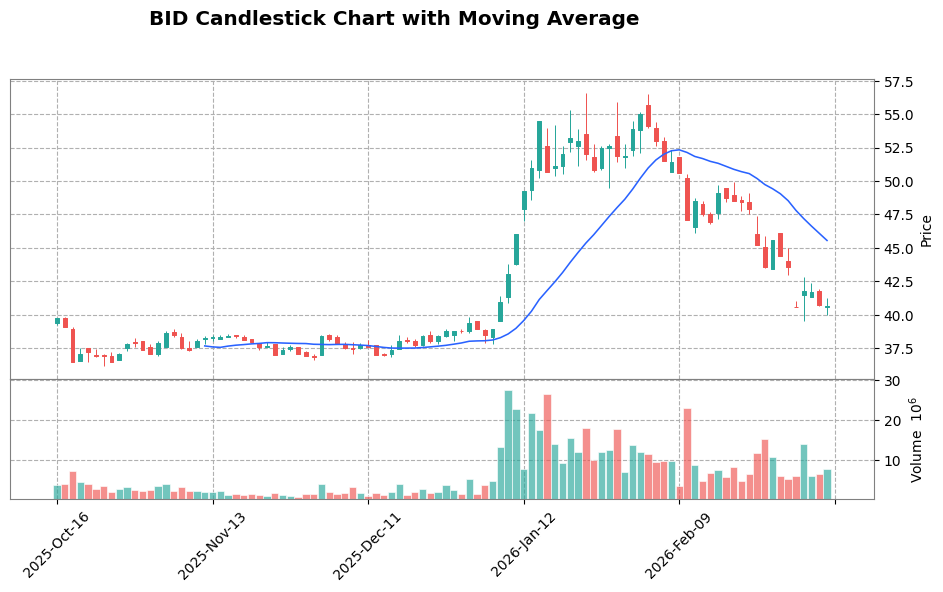

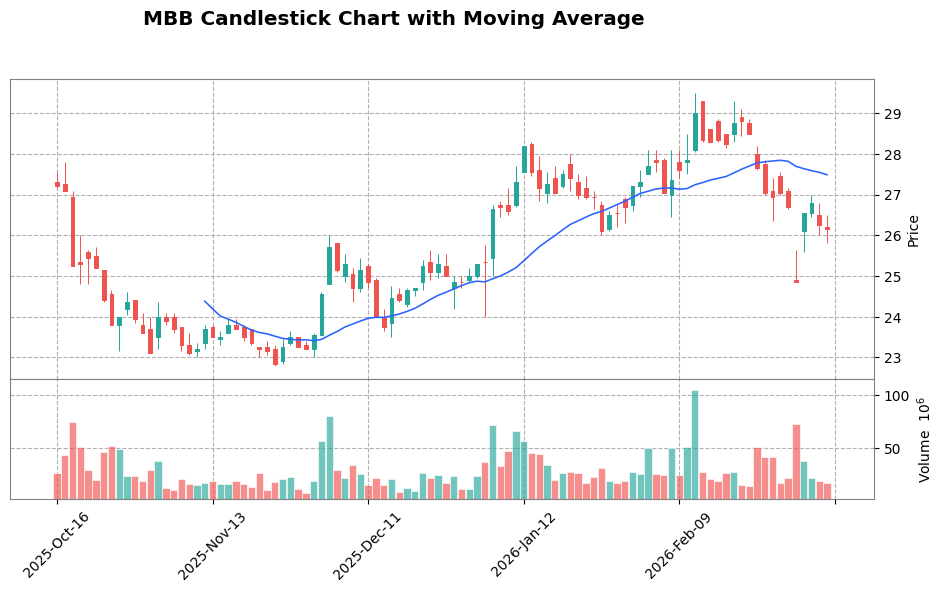

In [40]:
for name in ["VCB", "BID", "MBB"]:
    df = symbols[name].copy().tail(100)

    # mplfinance requires datetime index
    if "date" in df.columns:
        df.set_index("date", inplace=True)
    else:
        # fallback: use index as time
        df.index = pd.to_datetime(df.index)

    # Rename columns to required format
    df = df.rename(columns={
        "open": "Open",
        "close": "Close",
        "high": "High",
        "low": "Low",
        "volume": "Volume"
    })

    # Keep only needed columns
    df = df[["Open", "High", "Low", "Close", "Volume"]]
    # print(df.index[:5]) # Check DatetimeIndex
    # print(mpf.available_styles()) # View all chart style
    mpf.plot(
        df,
        type="candle",
        volume=True,
        mav=(20),   # moving averages (10, 20, 50)
        figsize=(12,6),
        title=f"{name} Candlestick Chart with Moving Average",
        style="tradingview"
    )
    

### e. Bollinger Bands

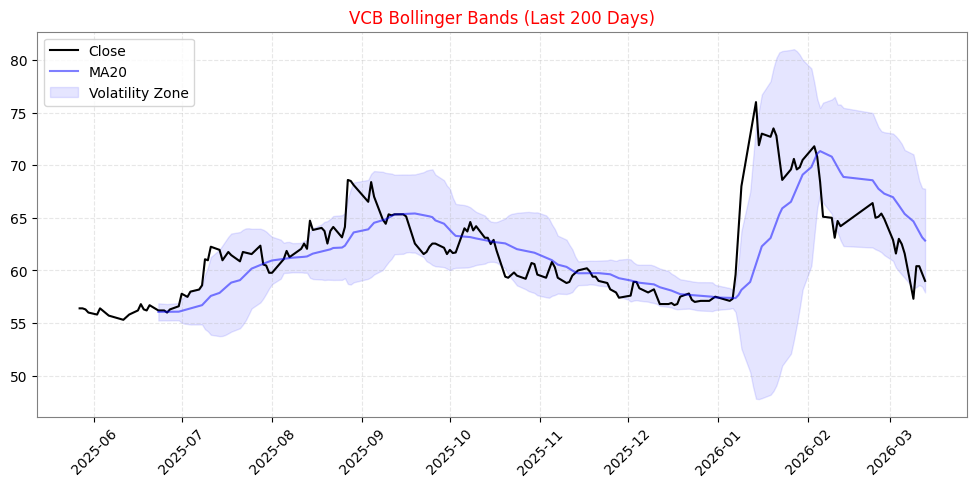

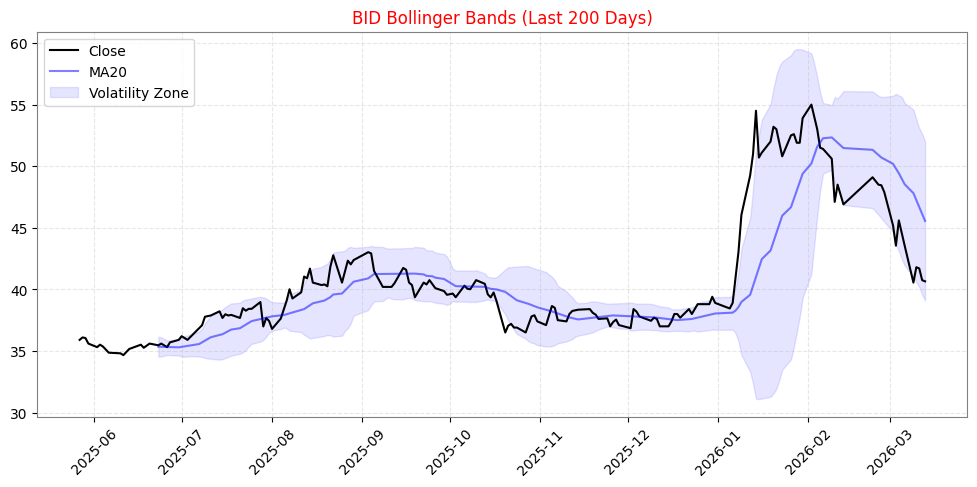

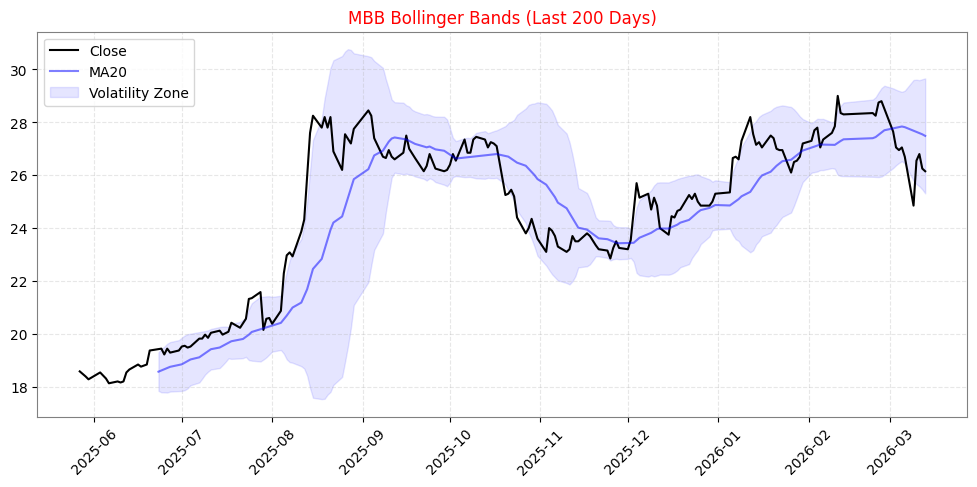

In [50]:
for name in ["VCB", "BID", "MBB"]:
    df = symbols[name].copy().tail(200)

    df["ma20"] = df["close"].rolling(20).mean()
    df["std20"] = df["close"].rolling(20).std()
    df["upper"] = df["ma20"] + 2 * df["std20"]
    df["lower"] = df["ma20"] - 2 * df["std20"]

    plt.figure(figsize=(12,5))
    # Using 'date' for the x-axis
    plt.plot(df["date"], df["close"], label="Close", color="black", linewidth=1.5)
    plt.plot(df["date"], df["ma20"], label="MA20", color="blue", alpha=0.5)
    
    # Shade the volatility zone
    plt.fill_between(df["date"], df["lower"], df["upper"], color='blue', alpha=0.1, label="Volatility Zone")

    plt.title(f"{name} Bollinger Bands (Last 200 Days)")
    plt.legend()
    plt.xticks(rotation=45) # Rotate dates so they don't overlap
    plt.grid(True, alpha=0.3)
    plt.show()

### f. Cumulative Return

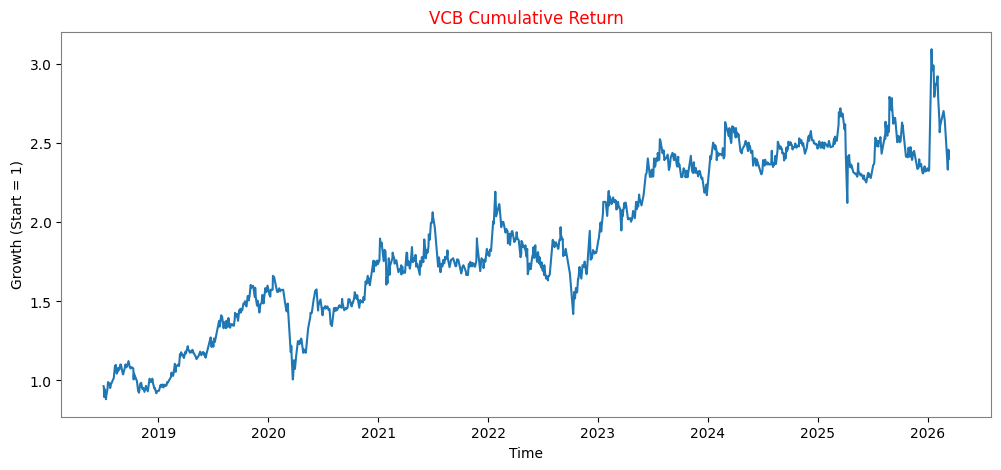

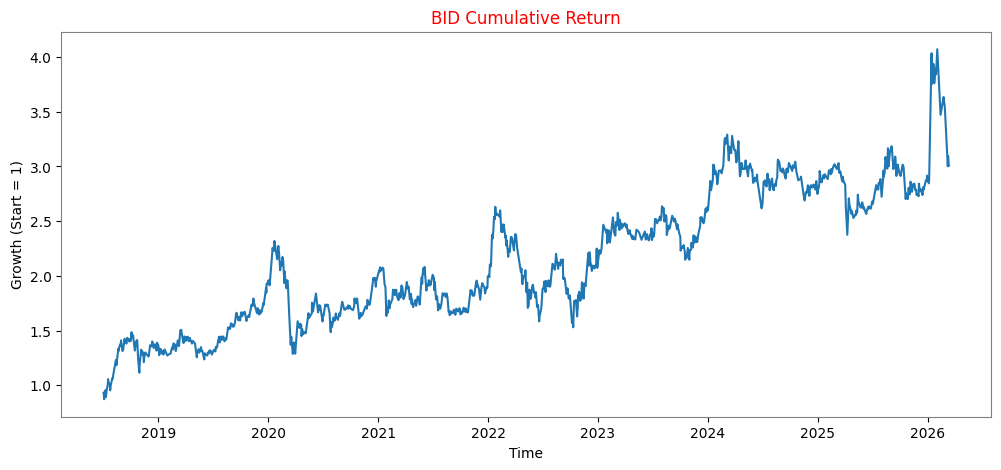

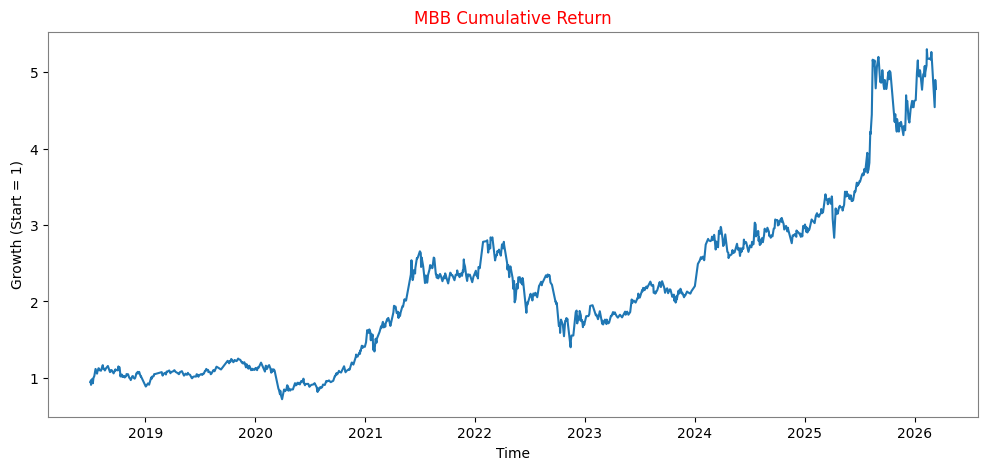

In [49]:
for name in ["VCB", "BID", "MBB"]:
    df = symbols[name].copy().set_index("date")

    df["return"] = df["close"].pct_change()
    df["cum_return"] = (1 + df["return"]).cumprod()

    plt.figure(figsize=(12,5))
    plt.plot(df["cum_return"])
    plt.title(f"{name} Cumulative Return")
    plt.xlabel("Time")
    plt.ylabel("Growth (Start = 1)")
    plt.grid()

    plt.show()

### g. Drawdown chart

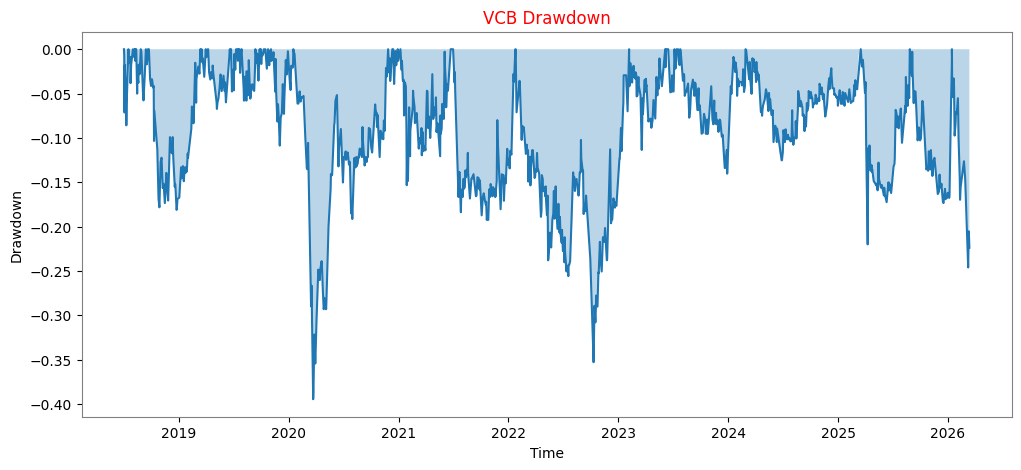

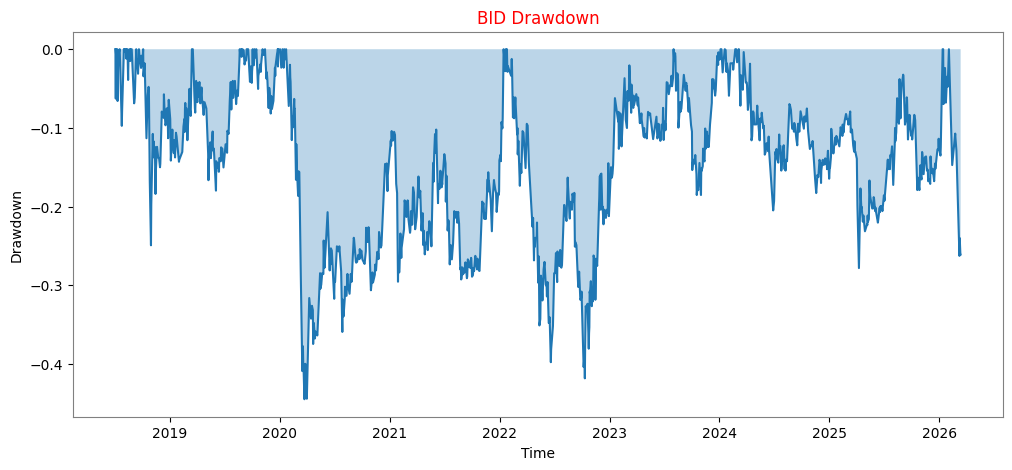

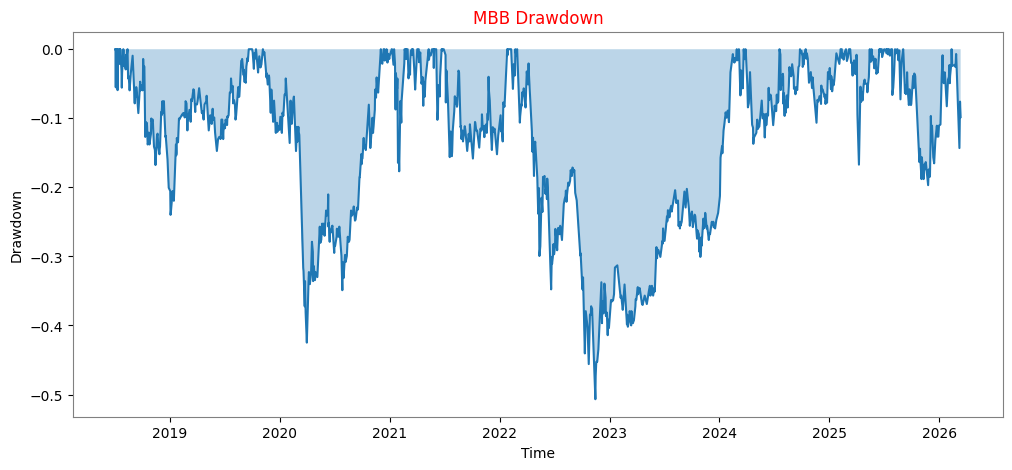

In [48]:
for name in ["VCB", "BID", "MBB"]:
    df = symbols[name].copy().set_index("date")

    df["return"] = df["close"].pct_change()
    df["cum_return"] = (1 + df["return"]).cumprod()

    df["cum_max"] = df["cum_return"].cummax()
    df["drawdown"] = (df["cum_return"] - df["cum_max"]) / df["cum_max"]

    plt.figure(figsize=(12,5))
    plt.plot(df["drawdown"])
    plt.fill_between(df.index, df["drawdown"], 0, alpha=0.3)

    plt.title(f"{name} Drawdown")
    plt.xlabel("Time")
    plt.ylabel("Drawdown")
    plt.grid()

    plt.show()

## 3. Feature Engineering

### Feature Construction

In [7]:
def make_features(
    df: pd.DataFrame,
    windows: tuple = (5, 10, 20),
    lags: tuple = (1, 2, 3, 5, 10, 20),
    add_technical: bool = True,
    eps: float = 1e-12,
) -> pd.DataFrame:
    required_cols = [
        "date", "symbol", "open", "high", "low", "close", "volume",
        "log_ret", "daily_vol"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    out = df.copy()
    out["date"] = pd.to_datetime(out["date"])
    out = out.sort_values(["symbol", "date"]).reset_index(drop=True)
    g = out.groupby("symbol", group_keys=False)

    out["ret_1"] = g["close"].pct_change()
    out["log_volume"] = np.log1p(out["volume"])
    daily_vol_safe = out["daily_vol"].replace(0, np.nan)

    def _rolling_zscore(s: pd.Series, win: int) -> pd.Series:
        mu = s.rolling(win, min_periods=win).mean()
        sd = s.rolling(win, min_periods=win).std()
        return (s - mu) / (sd + eps)

    def _rsi(series: pd.Series, period: int = 14) -> pd.Series:
        delta = series.diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        avg_gain = gain.rolling(period, min_periods=period).mean()
        avg_loss = loss.rolling(period, min_periods=period).mean()
        rs = avg_gain / avg_loss.replace(0, np.nan)
        return 100 - (100 / (1 + rs))

    def _ema(series: pd.Series, span: int) -> pd.Series:
        return series.ewm(span=span, adjust=False).mean()

    def _atr(gdf: pd.DataFrame, period: int = 14) -> pd.Series:
        prev_close = gdf["close"].shift(1)
        tr1 = gdf["high"] - gdf["low"]
        tr2 = (gdf["high"] - prev_close).abs()
        tr3 = (gdf["low"] - prev_close).abs()
        tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
        return tr.rolling(period, min_periods=period).mean()

    # 1) Multi-horizon standardized returns
    for lag in lags:
        out[f"log_ret_{lag}"] = g["close"].transform(
            lambda s, lag=lag: np.log(s / s.shift(lag))
        )

        ref_win = max(20, lag) if max(windows) >= 20 else max(windows)
        if f"volatility_{ref_win}" not in out.columns:
            out[f"volatility_{ref_win}"] = g["log_ret"].transform(
                lambda s, win=ref_win: s.rolling(win, min_periods=win).std()
            )

        out[f"z_log_ret_{lag}"] = g[f"log_ret_{lag}"].transform(
            lambda s, win=ref_win: _rolling_zscore(s, win)
        )
        out[f"log_ret_{lag}_vol_adj"] = out[f"log_ret_{lag}"] / (
            out[f"volatility_{ref_win}"].replace(0, np.nan) + eps
        )

    # 2) Volatility regime
    for win in windows:
        out[f"volatility_{win}"] = g["log_ret"].transform(
            lambda s, win=win: s.rolling(win, min_periods=win).std()
        )
        out[f"z_volatility_{win}"] = g[f"volatility_{win}"].transform(
            lambda s, win=win: _rolling_zscore(s, win)
        )

    # 3) Realized variance regime
    for win in windows:
        out[f"realized_var_{win}"] = g["log_ret"].transform(
            lambda s, win=win: (s ** 2).rolling(win, min_periods=win).mean()
        )
        out[f"z_realized_var_{win}"] = g[f"realized_var_{win}"].transform(
            lambda s, win=win: _rolling_zscore(s, win)
        )

    # 4) Distance from moving average
    for win in windows:
        ma = g["close"].transform(
            lambda s, win=win: s.rolling(win, min_periods=win).mean()
        )
        out[f"dist_ma_{win}_pct"] = (out["close"] - ma) / (ma + eps)
        out[f"z_dist_ma_{win}"] = g[f"dist_ma_{win}_pct"].transform(
            lambda s, win=win: _rolling_zscore(s, win)
        )

    # 5) MA spread trend features
    sorted_windows = tuple(sorted(set(windows)))
    for short_win, long_win in zip(sorted_windows[:-1], sorted_windows[1:]):
        ma_short = g["close"].transform(
            lambda s, win=short_win: s.rolling(win, min_periods=win).mean()
        )
        ma_long = g["close"].transform(
            lambda s, win=long_win: s.rolling(win, min_periods=win).mean()
        )
        spread = (ma_short / (ma_long + eps)) - 1.0
        out[f"ma_spread_{short_win}_{long_win}"] = spread
        out[f"ma_spread_{short_win}_{long_win}_vol_adj"] = spread / (
            out[f"volatility_{long_win}"].replace(0, np.nan) + eps
        )

    # 6) Explicit momentum family
    for win in windows:
        out[f"mom_{win}"] = g["close"].transform(
            lambda s, win=win: s / s.shift(win) - 1
        )
        out[f"mom_{win}_vol_adj"] = out[f"mom_{win}"] / (
            out[f"volatility_{win}"].replace(0, np.nan) + eps
        )

    # 7) Log-volume surprise
    out["log_vol_chg_1"] = g["log_volume"].diff()
    for win in windows:
        log_vol_ma = g["log_volume"].transform(
            lambda s, win=win: s.rolling(win, min_periods=win).mean()
        )
        log_vol_std = g["log_volume"].transform(
            lambda s, win=win: s.rolling(win, min_periods=win).std()
        )
        out[f"rel_log_volume_{win}"] = out["log_volume"] / (log_vol_ma + eps)
        out[f"z_log_volume_{win}"] = (out["log_volume"] - log_vol_ma) / (log_vol_std + eps)

    # 8) Volume instability
    for win in windows:
        out[f"log_volume_vol_{win}"] = g["log_volume"].transform(
            lambda s, win=win: s.rolling(win, min_periods=win).std()
        )
        out[f"z_log_volume_vol_{win}"] = g[f"log_volume_vol_{win}"].transform(
            lambda s, win=win: _rolling_zscore(s, win)
        )

    # 9) Return distribution shape
    for win in windows:
        out[f"mean_ret_{win}"] = g["log_ret"].transform(
            lambda s, win=win: s.rolling(win, min_periods=win).mean()
        )
        out[f"z_mean_ret_{win}"] = g[f"mean_ret_{win}"].transform(
            lambda s, win=win: _rolling_zscore(s, win)
        )

        if win >= 10:
            out[f"skew_ret_{win}"] = g["log_ret"].transform(
                lambda s, win=win: s.rolling(win, min_periods=win).skew()
            )
            out[f"kurt_ret_{win}"] = g["log_ret"].transform(
                lambda s, win=win: s.rolling(win, min_periods=win).kurt()
            )

    # 10) Range / gap / candle shock features
    out["hl_range"] = (out["high"] - out["low"]) / (out["close"] + eps)
    out["oc_return"] = (out["close"] - out["open"]) / (out["open"] + eps)
    out["co_gap"] = g["open"].transform(lambda s: s / s.shift(1) - 1)
    prev_close = g["close"].shift(1)
    out["open_to_prev_close"] = out["open"] / (prev_close + eps) - 1

    out["hl_range_vol_adj"] = out["hl_range"] / (daily_vol_safe + eps)
    out["oc_return_vol_adj"] = out["oc_return"] / (daily_vol_safe + eps)
    out["co_gap_vol_adj"] = out["co_gap"] / (daily_vol_safe + eps)
    out["open_to_prev_close_vol_adj"] = out["open_to_prev_close"] / (daily_vol_safe + eps)

    # Optional technicals: keep only normalized forms that are not too redundant
    if add_technical:
        out["rsi_14"] = g["close"].transform(_rsi)
        out["rsi_14_centered"] = (out["rsi_14"] - 50.0) / 50.0

        ema12 = g["close"].transform(lambda s: _ema(s, 12))
        ema26 = g["close"].transform(lambda s: _ema(s, 26))
        macd = ema12 - ema26
        macd_signal = macd.groupby(out["symbol"]).transform(
            lambda s: s.ewm(span=9, adjust=False).mean()
        )
        macd_hist = macd - macd_signal

        out["atr_14"] = (
            out.groupby("symbol", group_keys=False)
            .apply(_atr)
            .reset_index(level=0, drop=True)
        )
        atr_pct_safe = (out["atr_14"] / (out["close"] + eps)).replace(0, np.nan)

        out["macd_hist_atr_adj"] = macd_hist / (out["close"] * atr_pct_safe + eps)
        out["macd_hist_z_20"] = (
            out.groupby("symbol")["macd_hist_atr_adj"]
            .transform(lambda s: _rolling_zscore(s, 20))
        )

    # Calendar features
    out["day_of_week"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    out["quarter"] = out["date"].dt.quarter

    out = out.replace([np.inf, -np.inf], np.nan)
    return out

In [8]:
df_feat = make_features(labeled)
print(df_feat.columns.tolist())
print(df_feat.head(5))

/tmp/ipykernel_5777/774503889.py:186: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_atr)


['date', 'symbol', 'open', 'high', 'low', 'close', 'volume', 'log_ret', 'daily_vol', 'tb_label', 'tb_hit_date', 'tb_hit_type', 'tb_vertical_date', 'tb_upper_barrier', 'tb_lower_barrier', 'tb_event_log_return', 'ret_1', 'log_volume', 'log_ret_1', 'volatility_20', 'z_log_ret_1', 'log_ret_1_vol_adj', 'log_ret_2', 'z_log_ret_2', 'log_ret_2_vol_adj', 'log_ret_3', 'z_log_ret_3', 'log_ret_3_vol_adj', 'log_ret_5', 'z_log_ret_5', 'log_ret_5_vol_adj', 'log_ret_10', 'z_log_ret_10', 'log_ret_10_vol_adj', 'log_ret_20', 'z_log_ret_20', 'log_ret_20_vol_adj', 'volatility_5', 'z_volatility_5', 'volatility_10', 'z_volatility_10', 'z_volatility_20', 'realized_var_5', 'z_realized_var_5', 'realized_var_10', 'z_realized_var_10', 'realized_var_20', 'z_realized_var_20', 'dist_ma_5_pct', 'z_dist_ma_5', 'dist_ma_10_pct', 'z_dist_ma_10', 'dist_ma_20_pct', 'z_dist_ma_20', 'ma_spread_5_10', 'ma_spread_5_10_vol_adj', 'ma_spread_10_20', 'ma_spread_10_20_vol_adj', 'mom_5', 'mom_5_vol_adj', 'mom_10', 'mom_10_vol_adj',

### Feature Selection

In [9]:
exclude_cols = {
    "date", "symbol",
    "tb_label", "tb_hit_date", "tb_hit_type",
    "tb_vertical_date", "tb_upper_barrier", "tb_lower_barrier",
    "tb_event_log_return"
}

feature_cols = [c for c in df_feat.columns if c not in exclude_cols]

In [10]:
df_model = df_feat.dropna(subset=feature_cols + ["tb_label", "tb_hit_date"]).copy()
df_model.head()

,date,symbol,open,high,low,close,volume,log_ret,daily_vol,tb_label,...,co_gap_vol_adj,open_to_prev_close_vol_adj,rsi_14,rsi_14_centered,atr_14,macd_hist_atr_adj,macd_hist_z_20,day_of_week,month,quarter
39,2018-08-24,ACB,7.37,7.59,7.32,7.49,7614923,0.016151,0.014127,-1.0,...,0.483530,-9.603859e-12,77.343750,0.546875,0.195000,0.097972,1.160079,4,8,3
40,2018-08-27,ACB,7.53,7.63,7.49,7.49,3180882,0.000000,0.013950,-1.0,...,1.556296,3.828406e-01,76.229508,0.524590,0.192857,0.114755,1.363364,0,8,3
41,2018-08-28,ACB,7.51,7.57,7.49,7.51,5158953,0.002667,0.013653,-1.0,...,-0.194536,1.955754e-01,71.287129,0.425743,0.182143,0.124583,1.397286,1,8,3
42,2018-08-29,ACB,7.59,7.63,7.49,7.59,4615659,0.010596,0.013374,-1.0,...,0.796495,7.964954e-01,72.897196,0.457944,0.179286,0.141977,1.512931,2,8,3
43,2018-08-30,ACB,7.61,7.66,7.57,7.66,4212097,0.009180,0.013346,-1.0,...,0.197435,1.974353e-01,72.115385,0.442308,0.170714,0.168446,1.702158,3,8,3


In [11]:
# --------------------------------------------------
# Save labeled dataset
# --------------------------------------------------
df_model.to_csv(PROCESSED_OUT, index=False)
print("Saved:", PROCESSED_OUT)

Saved: ./data/processed_vn30_panel_daily.csv


### Data Explotary

In [12]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

def plot_tsne(
    df,
    feature_cols,
    label_col="tb_label",
    target_col="tb_event_log_return",
    sample_size=3000,
    perplexity=30,
    random_state=42,
):
    """
    Visualize whether features separate labels using t-SNE.
    """

    # ----------------------------
    # 1. Filter event rows (CRITICAL)
    # ----------------------------
    if target_col in df.columns:
        data = df[df[target_col].notna()].copy()
    else:
        data = df.copy()

    data = data.dropna(subset=feature_cols + [label_col])

    if len(data) == 0:
        raise ValueError("No valid data after filtering")

    # ----------------------------
    # 2. Subsample (t-SNE is slow)
    # ----------------------------
    if len(data) > sample_size:
        data = data.sample(sample_size, random_state=random_state)

    X = data[feature_cols].values
    y = data[label_col].values

    # ----------------------------
    # 3. Normalize (important for t-SNE)
    # ----------------------------
    X_scaled = StandardScaler().fit_transform(X)

    # ----------------------------
    # 4. Run t-SNE
    # ----------------------------
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca"
    )
    X_emb = tsne.fit_transform(X_scaled)

    # ----------------------------
    # 5. Plot (colored by label)
    # ----------------------------
    plt.figure(figsize=(7,6))

    unique_labels = np.unique(y)

    for label in unique_labels:
        mask = (y == label)
        plt.scatter(
            X_emb[mask, 0],
            X_emb[mask, 1],
            label=f"label={label}",
            alpha=0.6
        )

    plt.title("t-SNE: Feature space colored by label")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return X_emb

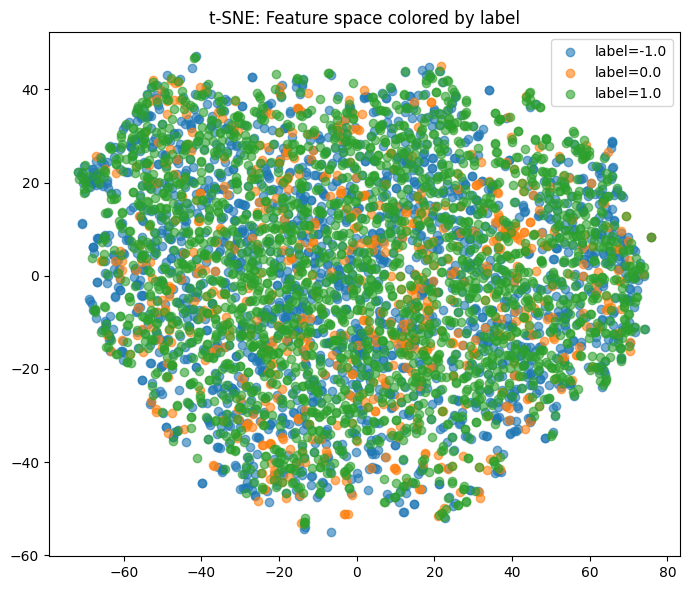

array([[ 68.41046   , -11.087957  ],
       [-46.081173  ,  24.134474  ],
       [-17.5045    , -31.889236  ],
       ...,
       [ 32.5743    ,  -0.58303326],
       [-35.534576  ,   5.1855702 ],
       [ -3.6945584 ,  23.699747  ]], shape=(5000, 2), dtype=float32)

In [13]:
plot_tsne(df_model, feature_cols, sample_size=5000)

## 4. Data Splitting

### Purged Time Series Cross-Validation

In [14]:
class PurgedTimeSeriesSplit:
    def __init__(
        self,
        n_splits=5,
        embargo_days=10,
        min_train_size=252
    ):
        self.n_splits = n_splits
        self.embargo_days = embargo_days
        self.min_train_size = min_train_size

    def split(self, df):
        df = df.sort_values("date").reset_index(drop=True).copy()
        unique_dates = np.array(sorted(df["date"].unique()))

        n_dates = len(unique_dates)
        fold_size = n_dates // (self.n_splits + 1)

        for fold in range(self.n_splits):
            val_start_idx = (fold + 1) * fold_size
            if fold == self.n_splits - 1:
                val_end_idx = n_dates - 1
            else:
                val_end_idx = (fold + 2) * fold_size - 1

            val_start_date = unique_dates[val_start_idx]
            val_end_date = unique_dates[val_end_idx]
            embargo_end_date = pd.Timestamp(val_end_date) + pd.Timedelta(days=self.embargo_days)

            val_mask = (df["date"] >= val_start_date) & (df["date"] <= val_end_date)

            train_mask = df["date"] < val_start_date

            # purge training rows whose event overlaps validation
            overlap_mask = train_mask & (df["tb_hit_date"] >= val_start_date)
            train_mask = train_mask & (~overlap_mask)

            # embargo after validation
            embargo_mask = (df["date"] > val_end_date) & (df["date"] <= embargo_end_date)
            train_mask = train_mask & (~embargo_mask)

            train_idx = np.where(train_mask)[0]
            val_idx = np.where(val_mask)[0]

            if len(train_idx) < self.min_train_size:
                continue
            if len(val_idx) == 0:
                continue

            yield train_idx, val_idx

### Time-series Train - Validation / Test Split

In [15]:
def chronological_holdout_split(df, test_start="2025-01-01"):
    trainval = df[df["date"] < pd.to_datetime(test_start)].copy()
    test = df[df["date"] >= pd.to_datetime(test_start)].copy()
    return trainval, test

In [16]:
trainval_df, test_df = chronological_holdout_split(df_model, test_start="2025-01-01")

In [17]:
print("trainval:", trainval_df["date"].min(), "->", trainval_df["date"].max(), len(trainval_df))
print("test    :", test_df["date"].min(), "->", test_df["date"].max(), len(test_df))

trainval: 2018-08-24 00:00:00 -> 2024-12-31 00:00:00 50801
test    : 2025-01-02 00:00:00 -> 2026-03-12 00:00:00 9367


## 5. Model Training

### Hyperparameter Tuning on Train/Validation
- Tune 5 candidate versions for each ML model on the train-validation split only.
- Select the best version using validation performance, then evaluate only the selected model on the test set.

In [18]:
# --------------------------------------------------
# 5 candidate versions for each ML family
# --------------------------------------------------
random_state = 42

model_families = {
    "xgb": [
        # (1) Conservative / low variance
        XGBClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8,
            objective="multi:softprob", eval_metric="mlogloss",
            random_state=random_state, n_jobs=-1,
        ),

        # (2) Balanced (usually strongest baseline)
        XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            objective="multi:softprob", eval_metric="mlogloss",
            random_state=random_state, n_jobs=-1,
        ),

        # (3) High capacity / slow learner
        XGBClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.02,
            subsample=0.8, colsample_bytree=0.8,
            objective="multi:softprob", eval_metric="mlogloss",
            random_state=random_state, n_jobs=-1,
        ),
    ],

    "rf": [
        # (1) Strong regularization (safe baseline)
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=200, max_depth=8, min_samples_leaf=10,
                class_weight="balanced_subsample",
                random_state=random_state, n_jobs=-1
            ))
        ]),

        # (2) Medium complexity
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=300, max_depth=10, min_samples_leaf=10,
                class_weight="balanced_subsample",
                random_state=random_state, n_jobs=-1
            ))
        ]),

        # (3) High flexibility (captures nonlinearities)
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=500, max_depth=None, min_samples_leaf=3,
                class_weight="balanced_subsample",
                random_state=random_state, n_jobs=-1
            ))
        ]),
    ],

    "svm": [
        # (1) Smooth nonlinear boundary
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(C=0.3, kernel="rbf", gamma="scale", class_weight="balanced"))
        ]),

        # (2) Strong nonlinear separation
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(C=3.0, kernel="rbf", gamma="scale", class_weight="balanced"))
        ]),

        # (3) Linear model (important baseline!)
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(C=1.0, kernel="linear", class_weight="balanced"))
        ]),
    ],

    "mlp": [
        # (1) Small network (low overfit risk)
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(64,),
                activation="relu",
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=300,
                early_stopping=True,
                random_state=random_state,
            ))
        ]),

        # (2) Balanced architecture
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=300,
                early_stopping=True,
                random_state=random_state,
            ))
        ]),

        # (3) Deep + regularized
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(512, 256, 128),
                activation="relu",
                alpha=1e-3,
                learning_rate_init=5e-4,
                max_iter=300,
                early_stopping=True,
                random_state=random_state,
            ))
        ]),
    ]
}

In [19]:
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

In [20]:
def encode_labels(y_train, y_other=None):
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)

    if y_other is None:
        return y_train_enc, le

    y_other_enc = le.transform(y_other)
    return y_train_enc, y_other_enc, le

In [21]:
def run_purged_cv(
    df,
    models: Dict[str, object],
    feature_cols,
    n_splits=5,
    embargo_days=10,
    min_train_size=252,
):
    df = df.sort_values(["date", "symbol"]).reset_index(drop=True).copy()

    cv = PurgedTimeSeriesSplit(
        n_splits=n_splits,
        embargo_days=embargo_days,
        min_train_size=min_train_size,
    )
    rows = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(df), start=1):
        train_df = df.iloc[train_idx].copy()
        val_df = df.iloc[val_idx].copy()

        X_train = train_df[feature_cols]
        y_train = train_df["tb_label"]

        X_val = val_df[feature_cols]
        y_val = val_df["tb_label"]

        print(f"Fold {fold}: train={len(train_df):,}, val={len(val_df):,}, "
              f"train_end={train_df["date"].max().date()}, val=[{val_df["date"].min().date()} -> {val_df["date"].max().date()}]")

        for model_name, model in models.items():
            clf = clone(model)

            if model_name == "xgb":
                y_train_enc, y_val_enc, le = encode_labels(y_train, y_val)
                clf.fit(X_train, y_train_enc)
                pred_enc = clf.predict(X_val)
                y_pred = le.inverse_transform(pred_enc.astype(int))
            else:
                clf.fit(X_train, y_train)
                y_pred = clf.predict(X_val)

            metrics = compute_metrics(y_val, y_pred)

            row = {
                "fold": fold,
                "model": model_name,
                "n_train": len(train_df),
                "n_val": len(val_df),
                **metrics
            }
            rows.append(row)

    cv_results = pd.DataFrame(rows)
    return cv_results

SyntaxError: f-string: unmatched '[' (964987316.py, line 29)

In [ ]:
all_cv_results = []

save_path = "results/cross_val.csv"

# Ensure the directory exists
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Resume if exists
if os.path.exists(save_path):
    print("[INFO] Loading previous results...")
    all_cv_results = pd.read_pickle(save_path).to_dict("records")

for family_name, candidates in model_families.items():
    for version_id, candidate in enumerate(candidates, start=1):

        # Skip already computed
        already_done = any(
            (r["family"] == family_name and r["version"] == version_id)
            for r in all_cv_results
        )
        if already_done:
            print(f"[SKIP] {family_name} v{version_id}")
            continue

        print(f"\n{'='*80}")
        print(f"Validate {family_name} - version {version_id}")
        print(f"{'='*80}")

        one_model_dict = {family_name: candidate}

        try:
            cv_res = run_purged_cv(
                trainval_df,
                models=one_model_dict,
                feature_cols=feature_cols,
                n_splits=5,
                embargo_days=10,
                min_train_size=252 * 2,
            ).copy()

            cv_res["family"] = family_name
            cv_res["version"] = version_id

            all_cv_results.extend(cv_res.to_dict("records"))

            # SAVE AFTER EACH SUCCESS ✅
            df_tmp = pd.DataFrame(all_cv_results)
            df_tmp.to_csv(save_path, index=False)

        except Exception as e:
            print(f"[ERROR] {family_name} v{version_id}: {e}")
            continue

# Final aggregation
all_cv_results = pd.DataFrame(all_cv_results)
all_cv_results.to_csv(save_path, index=False)


Validate xgb - version 1
Fold 1: train=8,609, val=9,098, train_end=2019-04-22, val=[2019-04-24 -> 2020-06-12]
Fold 2: train=17,784, val=9,086, train_end=2020-06-11, val=[2020-06-15 -> 2021-07-30]
Fold 3: train=26,711, val=9,117, train_end=2021-07-29, val=[2021-08-02 -> 2022-09-21]
Fold 4: train=35,929, val=9,117, train_end=2022-09-20, val=[2022-09-22 -> 2023-11-09]
Fold 5: train=45,040, val=9,152, train_end=2023-11-08, val=[2023-11-10 -> 2024-12-31]

Validate xgb - version 2
Fold 1: train=8,609, val=9,098, train_end=2019-04-22, val=[2019-04-24 -> 2020-06-12]
Fold 2: train=17,784, val=9,086, train_end=2020-06-11, val=[2020-06-15 -> 2021-07-30]
Fold 3: train=26,711, val=9,117, train_end=2021-07-29, val=[2021-08-02 -> 2022-09-21]
Fold 4: train=35,929, val=9,117, train_end=2022-09-20, val=[2022-09-22 -> 2023-11-09]
Fold 5: train=45,040, val=9,152, train_end=2023-11-08, val=[2023-11-10 -> 2024-12-31]

Validate xgb - version 3
Fold 1: train=8,609, val=9,098, train_end=2019-04-22, val=[2019-

In [ ]:
all_cv_results

,fold,model,n_train,n_val,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,family,version
0,1,xgb,8609,9098,0.388327,0.293877,0.276517,0.364295,0.322032,0.293877,xgb,1
1,2,xgb,17784,9086,0.370570,0.311653,0.267713,0.342764,0.491926,0.311653,xgb,1
2,3,xgb,26711,9117,0.439947,0.342660,0.312764,0.403026,0.376464,0.342660,xgb,1
3,4,xgb,35929,9117,0.446528,0.331741,0.314554,0.418937,0.401236,0.331741,xgb,1
4,5,xgb,45040,9152,0.438483,0.330969,0.299679,0.392453,0.283033,0.330969,xgb,1
5,1,xgb,8609,9098,0.385140,0.297618,0.288035,0.366500,0.301435,0.297618,xgb,2
6,2,xgb,17784,9086,0.395223,0.371389,0.355829,0.382730,0.443431,0.371389,xgb,2
7,3,xgb,26711,9117,0.460897,0.383133,0.381240,0.441759,0.449487,0.383133,xgb,2
8,4,xgb,35929,9117,0.438521,0.345915,0.345684,0.427181,0.364372,0.345915,xgb,2
9,5,xgb,45040,9152,0.452906,0.351202,0.330245,0.419107,0.434612,0.351202,xgb,2


In [ ]:
from google.colab import files

files.download(save_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --------------------------------------------------
# Average CV metrics for each family/version
# --------------------------------------------------
tuning_summary = (
    all_cv_results
    .groupby(["family", "version"], as_index=False)[
        ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1",
         "macro_precision", "macro_recall"]
    ]
    .mean()
    .sort_values(["family", "macro_f1"], ascending=[True, False])
)

tuning_summary

,family,version,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
2,mlp,3,0.431857,0.362489,0.359566,0.422505,0.386067,0.362489
1,mlp,2,0.426795,0.362904,0.359493,0.418104,0.378244,0.362904
0,mlp,1,0.426971,0.356507,0.350069,0.412447,0.388614,0.356507
4,rf,2,0.405777,0.405328,0.378488,0.409330,0.382081,0.405328
3,rf,1,0.399808,0.414506,0.376637,0.404731,0.384050,0.414506
5,rf,3,0.427940,0.357688,0.353003,0.413238,0.402960,0.357688
6,svm,1,0.412141,0.426991,0.393486,0.419483,0.395710,0.426991
7,svm,2,0.418647,0.404233,0.388755,0.422926,0.390382,0.404233
8,svm,3,0.396439,0.427369,0.383433,0.403219,0.388154,0.427369
11,xgb,3,0.427789,0.350709,0.341259,0.408563,0.405209,0.350709


In [ ]:
# --------------------------------------------------
# Best version for each model family
# --------------------------------------------------
best_versions = (
    tuning_summary
    .sort_values(["balanced_accuracy", "macro_f1", "family"], ascending=[False, False, True])
    .groupby("family", as_index=False)
    .first()
)

best_versions

,family,version,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,mlp,2,0.426795,0.362904,0.359493,0.418104,0.378244,0.362904
1,rf,1,0.399808,0.414506,0.376637,0.404731,0.384050,0.414506
2,svm,3,0.396439,0.427369,0.383433,0.403219,0.388154,0.427369
3,xgb,3,0.427789,0.350709,0.341259,0.408563,0.405209,0.350709


In [ ]:
# --------------------------------------------------
# Baseline models
# --------------------------------------------------
class ModeBaseline:
    def fit(self, X, y):
        y = pd.Series(y)
        self.mode_label_ = y.mode().iloc[0]
        return self

    def predict(self, X):
        return np.repeat(self.mode_label_, len(X))


class RandomBaseline:
    def __init__(self, random_state=42):
        self.random_state = random_state

    def fit(self, X, y):
        y = pd.Series(y)
        probs = y.value_counts(normalize=True).sort_index()
        self.labels_ = probs.index.to_numpy()
        self.probs_ = probs.values
        self.rng_ = np.random.default_rng(self.random_state)
        return self

    def predict(self, X):
        return self.rng_.choice(self.labels_, size=len(X), p=self.probs_)


class PrevLabelBaseline:
    """
    Previous observed label by symbol:
    - first test row of a symbol uses the last trainval label for that symbol
    - next test rows use previous test-row prediction input logic based on chronological order
    """
    def fit(self, train_df):
        last_lbl = (
            train_df.sort_values(["symbol", "date"])
            .groupby("symbol")["tb_label"]
            .last()
        )
        self.last_train_label_by_symbol_ = last_lbl.to_dict()
        self.global_mode_ = train_df["tb_label"].mode().iloc[0]
        return self

    def predict_from_df(self, df):
        df = df.sort_values(["symbol", "date"]).copy()
        preds = []

        for symbol, g in df.groupby("symbol", sort=False):
            prev = self.last_train_label_by_symbol_.get(symbol, self.global_mode_)
            for _ in range(len(g)):
                preds.append(prev)
                # naive persistence: keep using previous observed/persisted label
                prev = prev

        out = pd.Series(preds, index=df.index)
        out = out.reindex(df.index)
        return out.loc[df.index].values


## 6.Final evaluation

In [ ]:
def evaluate(
    clf,
    test_df,
    feature_cols,
):
    X_test = test_df[feature_cols]
    y_test = test_df["tb_label"]

    if clf.__class__.__name__ == "XGBClassifier":
        y_train_enc, y_test_enc, le = encode_labels(y_train, y_test)
        pred_enc = clf.predict(X_test)
        y_pred = le.inverse_transform(pred_enc.astype(int))
    else:
        y_pred = clf.predict(X_test)

    metrics = compute_metrics(y_test, y_pred)

    print("\nFinal test metrics:")
    print(metrics)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    labels_sorted = sorted(trainval_df["tb_label"].unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

    print("\nConfusion matrix (labels order =", labels_sorted, "):")
    print(cm)

    return {
        "model": clf,
        "metrics": metrics,
        "y_test": y_test,
        "y_pred": y_pred,
        "confusion_matrix": cm,
    }

In [ ]:
X_trainval = trainval_df[feature_cols]
y_train = trainval_df["tb_label"]   # IMPORTANT: create global y_train for your evaluate(...)

In [ ]:
# --------------------------------------------------
# Fit best ML models on full trainval
# --------------------------------------------------

best_ml_models = {}

for _, row in best_versions.iterrows():
    family = row["family"]
    version = int(row["version"])
    clf = clone(model_families[family][version - 1])
    print(f"Training {row["family"]} - version {row["version"]}...")
    if family == "xgb":
        y_train_enc, le = encode_labels(y_train)
        clf.fit(X_trainval, y_train_enc)
    else:
        clf.fit(X_trainval, y_train)

    best_ml_models[f"{family}_v{version}"] = clf

list(best_ml_models.keys())

Training mlp - version 2...
Training rf - version 1...
Training svm - version 3...
Training xgb - version 3...


['mlp_v2', 'rf_v1', 'svm_v3', 'xgb_v3']

In [ ]:
# --------------------------------------------------
# Evaluate best ML models with your existing evaluate(...)
# --------------------------------------------------
ml_test_results = []

for model_name, clf in best_ml_models.items():
    best_model_name = model_name   # IMPORTANT: create global expected by evaluate(...)
    out = evaluate(
        clf=clf,
        test_df=test_df,
        feature_cols=feature_cols,
    )

    ml_test_results.append({
        "name": model_name,
        "type": "ml",
        **out["metrics"],
    })

ml_test_results = pd.DataFrame(ml_test_results)
ml_test_results


Final test metrics:
{'accuracy': 0.4539340237002242, 'balanced_accuracy': np.float64(0.41556069886956254), 'macro_f1': 0.4197825369261574, 'weighted_f1': 0.45345084624228416, 'macro_precision': 0.4324848052558765, 'macro_recall': 0.41556069886956254}

Classification report:
              precision    recall  f1-score   support

        -1.0       0.40      0.50      0.45      3496
         0.0       0.36      0.28      0.32      1267
         1.0       0.53      0.47      0.50      4604

    accuracy                           0.45      9367
   macro avg       0.43      0.42      0.42      9367
weighted avg       0.46      0.45      0.45      9367


Confusion matrix (labels order = [np.float64(-1.0), np.float64(0.0), np.float64(1.0)] ):
[[1744  263 1489]
 [ 499  355  413]
 [2095  356 2153]]

Final test metrics:
{'accuracy': 0.40706736415074196, 'balanced_accuracy': np.float64(0.46849963935025957), 'macro_f1': 0.3979554607792098, 'weighted_f1': 0.41531061211292347, 'macro_precision': 0.

,name,type,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,mlp_v2,ml,0.453934,0.415561,0.419783,0.453451,0.432485,0.415561
1,rf_v1,ml,0.407067,0.468500,0.397955,0.415311,0.414217,0.468500
2,svm_v3,ml,0.427458,0.487183,0.417814,0.433995,0.428230,0.487183
3,xgb_v3,ml,0.499520,0.416008,0.426381,0.485906,0.492747,0.416008


In [ ]:
# --------------------------------------------------
# Evaluate baselines on test
# --------------------------------------------------

# fit baselines
mode_baseline = ModeBaseline().fit(X_trainval, y_train)
random_baseline = RandomBaseline(random_state=42).fit(X_trainval, y_train)
prev_baseline = PrevLabelBaseline().fit(trainval_df)

y_test = test_df["tb_label"]

baseline_rows = []

# Mode baseline
y_pred_mode = mode_baseline.predict(test_df[feature_cols])
baseline_rows.append({
    "name": "mode_baseline",
    "type": "baseline",
    **compute_metrics(y_test, y_pred_mode),
})

# Random baseline
y_pred_random = random_baseline.predict(test_df[feature_cols])
baseline_rows.append({
    "name": "random_baseline",
    "type": "baseline",
    **compute_metrics(y_test, y_pred_random),
})

# Previous-label baseline
y_pred_prev = prev_baseline.predict_from_df(test_df)
baseline_rows.append({
    "name": "prev_label_baseline",
    "type": "baseline",
    **compute_metrics(y_test, y_pred_prev),
})

baseline_test_results = pd.DataFrame(baseline_rows)
baseline_test_results

,name,type,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,mode_baseline,baseline,0.491513,0.333333,0.219693,0.323946,0.163838,0.333333
1,random_baseline,baseline,0.394256,0.332853,0.332003,0.394452,0.332733,0.332853
2,prev_label_baseline,baseline,0.377282,0.327857,0.248116,0.293920,0.314047,0.327857


In [ ]:
# --------------------------------------------------
# Final comparison: best ML models vs 3 baselines
# --------------------------------------------------
final_comparison = pd.concat(
    [ml_test_results, baseline_test_results],
    ignore_index=True
).sort_values(["macro_f1", "balanced_accuracy"], ascending=False)

final_comparison

,name,type,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
3,xgb_v3,ml,0.499520,0.416008,0.426381,0.485906,0.492747,0.416008
0,mlp_v2,ml,0.453934,0.415561,0.419783,0.453451,0.432485,0.415561
2,svm_v3,ml,0.427458,0.487183,0.417814,0.433995,0.428230,0.487183
1,rf_v1,ml,0.407067,0.468500,0.397955,0.415311,0.414217,0.468500
5,random_baseline,baseline,0.394256,0.332853,0.332003,0.394452,0.332733,0.332853
6,prev_label_baseline,baseline,0.377282,0.327857,0.248116,0.293920,0.314047,0.327857
4,mode_baseline,baseline,0.491513,0.333333,0.219693,0.323946,0.163838,0.333333


In [ ]:
import joblib
import os

# Define the directory to save models
MODELS_DIR = "./models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Iterate through the best_ml_models and save each one
for model_name, model in best_ml_models.items():
    filename = os.path.join(MODELS_DIR, f"{model_name}.joblib")
    joblib.dump(model, filename)
    print(f"Saved model '{model_name}' to {filename}")

Saved model 'mlp_v2' to ./models/mlp_v2.joblib
Saved model 'rf_v1' to ./models/rf_v1.joblib
Saved model 'svm_v3' to ./models/svm_v3.joblib
Saved model 'xgb_v3' to ./models/xgb_v3.joblib


In [ ]:
import shutil
from google.colab import files

# Define the folder to download and the name for the zip file
folder_to_zip = MODELS_DIR  # Assuming MODELS_DIR is defined from previous steps
zip_filename = "models.zip"

# Create a zip archive of the folder
shutil.make_archive(folder_to_zip, 'zip', folder_to_zip)

# Download the zip file
files.download(zip_filename)
print(f"The folder '{folder_to_zip}' has been zipped to '{zip_filename}' and is now available for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The folder './models' has been zipped to 'models.zip' and is now available for download.


The models have been saved to the `./models` directory.